# Weakly Supervised 3D Disease Localization — MacBook Pro M5 (Yerel)

BB annotasyonları + TotalSegmentator → **3D hastalık maskesi** (pseudo-label yok)

| Adım | İçerik |
|------|--------|
| 1 | Kontrol (MPS, paketler, dizinler) |
| 2 | Kullanıcı ayarları |
| 3 | Ortam değişkenleri |
| **4** | **Maske üretimi** (`generate_weak_masks`) |
| 5 | İstatistikler |
| 6 | CT + Maske görselleştirme |
| 7 | Analiz: BB Coverage & Z-range |


## [1] Kontrol — MPS, Paketler, Dizinler

In [24]:
import sys
from pathlib import Path

# Proje kökünü sys.path'e ekle
PROJECT = Path('abdomen_project').resolve()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

# MPS / PyTorch kontrolü
import torch
mps_ok = torch.backends.mps.is_available()
print(f'PyTorch  : {torch.__version__}')
print(f'MPS      : {"OK (Apple Silicon GPU)" if mps_ok else "YOK"}')

# Paket kontrolleri
import SimpleITK as sitk, pydicom, pandas, numpy
print(f'SimpleITK: {sitk.Version()}')
print(f'pydicom  : {pydicom.__version__}')
print(f'pandas   : {pandas.__version__}')

# TotalSegmentator Python API kontrolü (CLI değil)
from totalsegmentator.python_api import totalsegmentator as _ts_api
print('TotalSegmentator Python API: OK')

# Dizin kontrolleri
BASE = Path('.')
checks = {
    'Bilgi.xlsx'                          : BASE / 'Bilgi.xlsx',
    'Yarışma Veri Seti/'                  : BASE / 'Yarışma Veri Seti',
    'abdomen_project/src/weak_seg.py'     : PROJECT / 'src' / 'weak_seg.py',
    'outputs/splits/manifest.csv'         : PROJECT / 'outputs' / 'splits' / 'manifest.csv',
}
print()
all_ok = True
for label, path in checks.items():
    ok = path.exists()
    print(f'  [{"OK" if ok else "EKSIK"}] {label}')
    if not ok: all_ok = False
print()
print('Hazır!' if all_ok else 'Eksik dosyalar var — lütfen kontrol edin.')

PyTorch  : 2.8.0
MPS      : OK (Apple Silicon GPU)
SimpleITK: SimpleITK Version: 2.5.3 (ITK 5.4)
Compiled: Nov 20 2025 23:23:20

pydicom  : 2.4.4
pandas   : 2.3.3
TotalSegmentator Python API: OK

  [OK] Bilgi.xlsx
  [OK] Yarışma Veri Seti/
  [OK] abdomen_project/src/weak_seg.py
  [OK] outputs/splits/manifest.csv

Hazır!


## [2] Kullanıcı Ayarları — yalnızca bu hücreyi düzenleyin

In [25]:
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════

BASE        = Path('.').resolve()                     # abdomen/ klasörü
PROJECT_DIR = BASE / 'abdomen_project'
TRAIN_DIR   = BASE / 'Eğitim Verisi'                 # Zip açılmışsa
TEST_DIR    = BASE / 'Yarışma Veri Seti'
SPLITS_DIR  = PROJECT_DIR / 'outputs' / 'splits'
OUT_DIR     = PROJECT_DIR / 'outputs' / 'seg_data' / 'weak_disease_masks'

TOTALSEG_FAST = True    # Önerilir (roi_subset zaten hız sağlıyor)
DEVICE        = 'mps'   # 'mps' | 'cpu'  (M5 için mps)
N_WORKERS     = 4       # Paralel DICOM→NIfTI worker sayısı
LIMIT         = None   # Debug: kaç vaka (None = hepsi, 5 = test)

# ══════════════════════════════════════════════════════════════════════════════

print(f'Base        : {BASE}')
print(f'Project     : {PROJECT_DIR}')
print(f'Train dir   : {TRAIN_DIR} [{"OK" if TRAIN_DIR.exists() else "yok—zipped?"}]')
print(f'Test dir    : {TEST_DIR} [{"OK" if TEST_DIR.exists() else "EKSIK"}]')
print(f'Splits dir  : {SPLITS_DIR} [{"OK" if SPLITS_DIR.exists() else "EKSIK"}]')
print(f'Output dir  : {OUT_DIR}')
print(f'Device      : {DEVICE}')
print(f'Workers     : {N_WORKERS}')
print(f'Limit       : {LIMIT}')

Base        : /Users/ramazanpolat/Desktop/datasets/abdomen
Project     : /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project
Train dir   : /Users/ramazanpolat/Desktop/datasets/abdomen/Eğitim Verisi [yok—zipped?]
Test dir    : /Users/ramazanpolat/Desktop/datasets/abdomen/Yarışma Veri Seti [OK]
Splits dir  : /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs/splits [OK]
Output dir  : /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs/seg_data/weak_disease_masks
Device      : mps
Workers     : 4
Limit       : None


## [3] Ortam Değişkenlerini Ayarla

In [26]:
import os

OUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ['ABDOMEN_PROJECT_ROOT'] = str(PROJECT_DIR)
os.environ['ABDOMEN_DATA_ROOT']    = str(BASE)
os.environ['ABDOMEN_TRAIN_DIR']    = str(TRAIN_DIR)
os.environ['ABDOMEN_TEST_DIR']     = str(TEST_DIR)
os.environ['ABDOMEN_BILGI_XLSX']   = str(BASE / 'Bilgi.xlsx')
os.environ['ABDOMEN_SPLIT_DIR']    = str(SPLITS_DIR)
os.environ['ABDOMEN_SEG_DATA_DIR'] = str(OUT_DIR.parent)  # seg_data/
os.environ['ABDOMEN_OUT_DIR']      = str(PROJECT_DIR / 'outputs')
# MPS için CUDA_VISIBLE_DEVICES ayarlanmaz

for k, v in sorted(os.environ.items()):
    if k.startswith('ABDOMEN_'):
        print(f'{k:30s} = {v}')

ABDOMEN_BILGI_XLSX             = /Users/ramazanpolat/Desktop/datasets/abdomen/Bilgi.xlsx
ABDOMEN_DATA_ROOT              = /Users/ramazanpolat/Desktop/datasets/abdomen
ABDOMEN_OUT_DIR                = /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs
ABDOMEN_PROJECT_ROOT           = /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project
ABDOMEN_SEG_DATA_DIR           = /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs/seg_data
ABDOMEN_SPLIT_DIR              = /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs/splits
ABDOMEN_TEST_DIR               = /Users/ramazanpolat/Desktop/datasets/abdomen/Yarışma Veri Seti
ABDOMEN_TRAIN_DIR              = /Users/ramazanpolat/Desktop/datasets/abdomen/Eğitim Verisi


## [4] generate_weak_masks — 3D Hastalık Maskesi Üretimi

**Optimizasyonlar (M5 için):**
- `device='mps'` → Apple Silicon GPU (~25 sn/vaka)
- `roi_subset` → 104 yerine 7 organ
- Paralel DICOM→NIfTI (4 worker)

| Konfigürasyon | Süre/vaka |
|---|---|
| Eski (CPU, 104 organ) | ~6-7 dk |
| **Yeni (MPS, 7 organ)** | **~25 sn** |

> 735 vaka × 25 sn ≈ **~5 saat** (arka planda çalıştırılabilir)

In [27]:
from src.weak_seg import generate_weak_masks

print(f'Çıktı dizini : {OUT_DIR}')
print(f'Device       : {DEVICE}')
print(f'Fast mode    : {TOTALSEG_FAST}')
print(f'Workers      : {N_WORKERS}')
print(f'Limit        : {LIMIT}')
print('-' * 50)

generate_weak_masks(
    limit=LIMIT,
    out_dir=OUT_DIR,
    totalseg_fast=TOTALSEG_FAST,
    device=DEVICE,
    n_dicom_workers=N_WORKERS,
)

Çıktı dizini : /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs/seg_data/weak_disease_masks
Device       : mps
Fast mode    : True
Workers      : 4
Limit        : None
--------------------------------------------------
Cihaz: mps
  [uyarı] 307 vaka dizini bulunamadı, atlanıyor.
BB annotasyonlu vaka: 652  |  işlenecek: 340
DICOM→NIfTI paralel dönüşüm (4 worker)...


DICOM→NIfTI:   5%|▌         | 18/340 [00:05<01:34,  3.39it/s]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8f9cf9680): Non uniform sampling or missing slices detected,  maximum nonuniformity:134.373

ImageSeriesReader (0x8dfc8b900): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.12713

DICOM→NIfTI:  16%|█▌        | 55/340 [00:41<03:16,  1.45it/s]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8e42cc180): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000100174

DICOM→NIfTI:  19%|█▉        | 64/340 [00:46<02:11,  2.10it/s]

  [skip dicom] case 20071: Exception thrown in SimpleITK ImageSeriesReader_Execute: /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageFileReader.hxx:338:
ImageIO returns IO region that does not fully contain the requested region. Requested region: ImageRegion (0x30cbd6ba8)
  Dimension: 3
  Index: [0, 0, 0]
  Size: [643, 512, 1]
StreamableRegion region: ImageRegion (0x30cbd6be0)
  Dimension: 3
  Index: [0, 0, 0]
  Size: [512, 512, 1]



DICOM→NIfTI:  32%|███▏      | 109/340 [01:42<04:05,  1.06s/it]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8e42cc000): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.622892

DICOM→NIfTI:  40%|████      | 136/340 [02:13<03:54,  1.15s/it]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8f9cf9c80): Non uniform sampling or missing slices detected,  maximum nonuniformity:12.08

DICOM→NIfTI:  46%|████▌     | 157/340 [02:35<02:44,  1.11it/s]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x8e42cc180): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.001

DICOM→NIfTI:  56%|█████▌    | 191/340 [03:18<02:31,  1.02s/it]WARNING:

  [skip] case 20016: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.


...

Shape of output image is very big. Setting nr_threads_saving=1 to save memory.


TotalSeg+Maske:  90%|█████████ | 306/340 [2:42:36<19:28, 34.37s/it]

Shape of output image is very big. Setting nr_threads_saving=1 to save memory.


TotalSeg+Maske: 100%|██████████| 340/340 [3:00:47<00:00, 31.90s/it]



Sınıf voxel sayıları:
  acute_cholecystitis                : 6,542,246
  kidney_ureter_stone                : 42,749,822
  acute_pancreatitis                 : 15,691,843
  aortic_aneurysm_dissection         : 12,671,261
  acute_appendicitis                 : 5,623,875
  acute_diverticulitis               : 9,536,507

Bitti — işlenen: 338, atlanan: 2
Maskeler: /Users/ramazanpolat/Desktop/datasets/abdomen/abdomen_project/outputs/seg_data/weak_disease_masks


## [5] İstatistikler

İşlenen vaka: 652

  acute_cholecystitis                :    6,542,246  ██████
  kidney_ureter_stone                :   42,749,822  ████████████████████████████████████████
  acute_pancreatitis                 :   15,691,843  ██████████████
  aortic_aneurysm_dissection         :   12,671,261  ███████████
  acute_appendicitis                 :    5,623,875  █████
  acute_diverticulitis               :    9,536,507  ████████


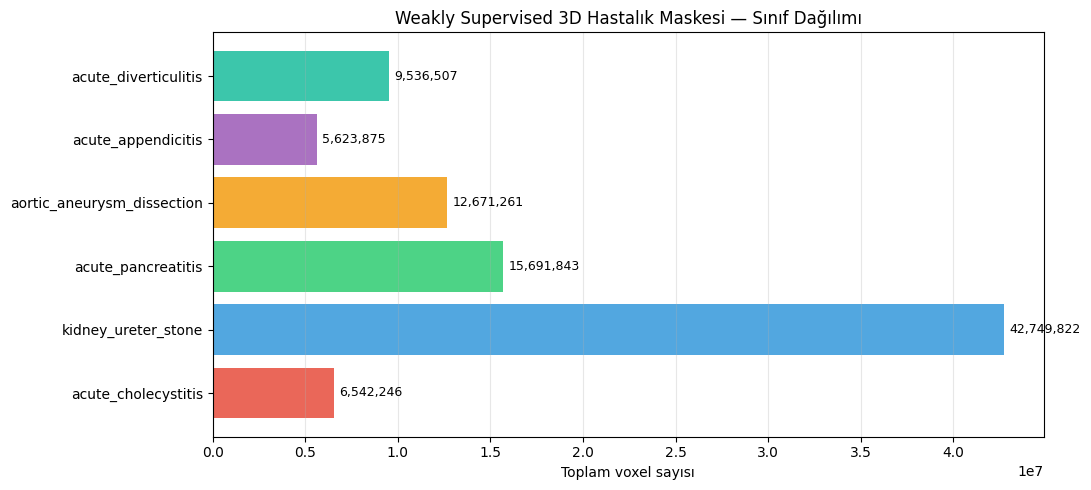

In [28]:
%matplotlib inline
import json
import matplotlib.pyplot as plt

stats_path = OUT_DIR / 'stats.json'
assert stats_path.exists(), f'stats.json bulunamadi: {stats_path}'

with open(stats_path) as f:
    stats = json.load(f)

classes = list(stats['voxel_counts'].keys())
counts  = list(stats['voxel_counts'].values())

print(f'İşlenen vaka: {stats["processed_cases"]}')
print()
for cls, n in zip(classes, counts):
    bar = '█' * min(40, int(n / max(counts) * 40)) if max(counts) else ''
    print(f'  {cls:35s}: {n:>12,}  {bar}')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
bars = ax.barh(classes, counts, color=colors, alpha=0.85)
ax.bar_label(bars, labels=[f'{n:,}' for n in counts], padding=4, fontsize=9)
ax.set_xlabel('Toplam voxel sayısı')
ax.set_title('Weakly Supervised 3D Hastalık Maskesi — Sınıf Dağılımı')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## [6] CT + Maske Görselleştirme

In [29]:
# Hangi vakayı görselleştirmek istiyorsunuz?
VIZ_CASE_ID = None   # None = ilk mevcut maske, ya da örn: 20001

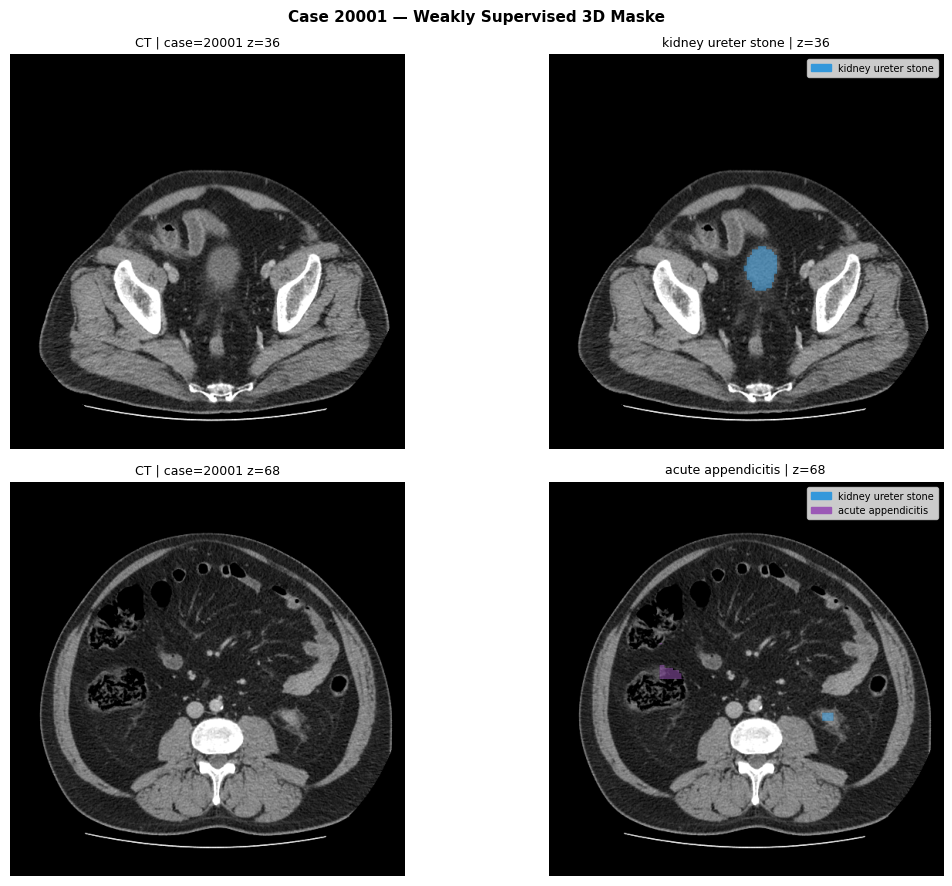

In [30]:
%matplotlib inline
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from src.config import SUPER_CLASSES, RAW_TRAIN_DIR, RAW_TEST_DIR
from src.dicom_utils import load_series, window_hu, Window

COLORS   = [None,'#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
SOFT_WIN = Window('soft_tissue', level=40, width=400)

masks = sorted(OUT_DIR.glob('*_disease.nii.gz'))
if not masks:
    print('Maske bulunamadi — önce [4] hücresini çalıştırın.')
else:
    if VIZ_CASE_ID:
        mask_path = OUT_DIR / f'ABE_{VIZ_CASE_ID:05d}_disease.nii.gz'
    else:
        mask_path = masks[0]

    cid = int(mask_path.stem.split('_')[1])
    case_dir = next((b/str(cid) for b in (RAW_TRAIN_DIR, RAW_TEST_DIR)
                     if (b/str(cid)).is_dir()), None)

    arr    = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
    series = load_series(case_dir)

    # Hastalık içeren kesitlerden birini seç
    dis_zs = np.where(arr.max(axis=(1,2)) > 0)[0]
    if len(dis_zs) == 0:
        print('Bu vakada maske içeriği yok.')
    else:
        # Her sınıf için orta kesiti göster
        cls_in_mask = [c for c in range(1,7) if (arr==c).any()]
        fig, axes = plt.subplots(len(cls_in_mask), 2,
                                 figsize=(12, 4.5*len(cls_in_mask)))
        if len(cls_in_mask) == 1:
            axes = axes[np.newaxis,:]

        for ri, cid_cls in enumerate(cls_in_mask):
            cls_zs = np.where(arr.max(axis=(1,2)) == cid_cls)[0]
            z = cls_zs[len(cls_zs)//2]
            ct  = window_hu(series.hu[z], SOFT_WIN)
            msk = arr[z]

            ax = axes[ri,0]
            ax.imshow(ct, cmap='gray')
            ax.set_title(f'CT | case={cid} z={z}', fontsize=9)
            ax.axis('off')

            ax = axes[ri,1]
            ax.imshow(ct, cmap='gray')
            ov = np.zeros((*ct.shape,4), dtype=np.float32)
            patches = []
            for c2, clr in enumerate(COLORS[1:],1):
                reg = msk==c2
                if not reg.any(): continue
                rgba = mcolors.to_rgba(clr)
                ov[reg] = (*rgba[:3], 0.55)
                patches.append(mpatches.Patch(color=clr,
                    label=SUPER_CLASSES[c2-1].replace('_',' ')))
            ax.imshow(ov)
            if patches: ax.legend(handles=patches, loc='upper right', fontsize=7)
            ax.set_title(f'{SUPER_CLASSES[cid_cls-1].replace("_"," ")} | z={z}', fontsize=9)
            ax.axis('off')

        plt.suptitle(f'Case {cid} — Weakly Supervised 3D Maske', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

## [7] Analiz: BB Coverage & Z-Range Uyumu

In [31]:
import pandas as pd
from src.config import RAW_PATHOLOGY_TO_SUPER, SUPER_CLASSES

sheets  = pd.read_excel(BASE / 'Bilgi.xlsx', sheet_name=None)
all_ann = pd.concat([
    sheets['TRAIININGDATA'].assign(source='train'),
    sheets['COMPETITIONDATA'].assign(source='comp'),
], ignore_index=True)

def parse_bb(raw):
    try:
        a,b = raw.split('-')
        x1,y1 = map(int,a.split(','))
        x2,y2 = map(int,b.split(','))
        return (x1,y1,x2,y2) if x2>x1 and y2>y1 else None
    except: return None

records = []
for mask_path in sorted(OUT_DIR.glob('*_disease.nii.gz')):
    cid = int(mask_path.stem.split('_')[1])
    case_dir_ = next((b/str(cid) for b in (RAW_TRAIN_DIR,RAW_TEST_DIR)
                      if (b/str(cid)).is_dir()), None)
    if not case_dir_: continue
    try:
        ser_  = load_series(case_dir_)
        arr_  = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
        idx_  = {img_id:i for i,img_id in enumerate(ser_.image_ids)}
        rows_ = all_ann[(all_ann['Case Number']==cid) &
                        (all_ann['Type']=='Bounding Box')]
        for _,r in rows_.iterrows():
            bb  = parse_bb(str(r['Data']))
            sid = RAW_PATHOLOGY_TO_SUPER.get(r['Class'])
            if bb is None or sid is None: continue
            z   = idx_.get(int(r['Image Id']))
            if z is None: continue
            gt   = np.zeros(arr_[z].shape,np.uint8); gt[bb[1]:bb[3],bb[0]:bb[2]]=1
            pred = (arr_[z]==sid+1).astype(np.uint8)
            tp   = (gt&pred).sum()
            records.append({
                'case'    : cid,
                'class'   : SUPER_CLASSES[sid].replace('_',' '),
                'BB_px'   : int(gt.sum()),
                'Mask_px' : int(pred.sum()),
                'TP_px'   : int(tp),
                'BB_Cov%' : round(tp/gt.sum()*100,1) if gt.sum() else 0.0,
                'MaskPr%' : round(tp/pred.sum()*100,1) if pred.sum() else 0.0,
            })
    except Exception as e:
        print(f'  [skip] {cid}: {e}')

if records:
    df_m = pd.DataFrame(records)
    print('Sınıf bazında ortalama metrikler:')
    print(df_m.groupby('class')[['BB_Cov%','MaskPr%']].mean().round(1).to_string())
    print(f'\nGenel BB Coverage  : {df_m["BB_Cov%"].mean():.1f}%')
    print(f'Genel Mask Precision: {df_m["MaskPr%"].mean():.1f}%')
    display(df_m)
else:
    print('Metrik hesaplanamadi.')

/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python3.9/site-packages/pydicom/pixel_data_handlers/numpy_handler.py:250: UserWarning: The length of the pixel data in the dataset (525312 bytes) indicates it contains excess padding. 1024 bytes will be removed from the end of the data
  warnings.warn(msg)


Sınıf bazında ortalama metrikler:
                            BB_Cov%  MaskPr%
class                                       
acute appendicitis             79.7     92.2
acute cholecystitis            96.4     99.8
acute diverticulitis           82.6     99.1
acute pancreatitis             91.2     93.1
aortic aneurysm dissection     52.3    100.0
kidney ureter stone            95.3     94.7

Genel BB Coverage  : 78.3%
Genel Mask Precision: 96.1%


,case,class,BB_px,Mask_px,TP_px,BB_Cov%,MaskPr%
0,20001,kidney ureter stone,132,132,132,100.0,100.0
1,20001,kidney ureter stone,100,100,100,100.0,100.0
2,20001,acute appendicitis,209,209,209,100.0,100.0
3,20001,acute appendicitis,255,255,255,100.0,100.0
4,20001,acute appendicitis,289,289,289,100.0,100.0
...,...,...,...,...,...,...,...
10104,20358,aortic aneurysm dissection,299,22,22,7.4,100.0
10105,20358,aortic aneurysm dissection,276,42,42,15.2,100.0
10106,20358,aortic aneurysm dissection,360,48,48,13.3,100.0
10107,20358,aortic aneurysm dissection,391,33,33,8.4,100.0
